# Conservación del área y simplecticidad de la proyección GC

Este estudio reúne el barrido de paso de `test_dX_dY` con el diagnóstico del mapa físico proyectado $G_n=P\Phi_n\cdots\Phi_1E$. Todas las ejecuciones comparten potencial, geometría, radio de Larmor y frecuencia de acoplamiento.

Se emplean dos resoluciones del mismo contorno:

- un contorno denso para medir y animar el área durante $0\leq t\leq6\pi$;
- un contorno diagnóstico reducido para calcular por diferencias finitas los jacobianos proyectados.

La reducción es necesaria porque el coste del jacobiano crece con el número de vértices. El área poligonal y el defecto simpléctico son diagnósticos relacionados, pero no idénticos.

In [1]:
from pathlib import Path
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation as mpl_animation
import numpy as np
from IPython.display import HTML, display


def find_project_root(start):
    """Find the project whether Jupyter starts at its root or a notebook folder."""
    location = Path(start).resolve()
    for candidate in (location, *location.parents):
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise RuntimeError('No se encontró la raíz del proyecto.')


def display_animation(animation):
    """Display a compact animation, with a JavaScript fallback."""
    # The default 20 MB limit is too small for the dense area animation.
    mpl.rcParams['animation.embed_limit'] = 100.0
    if mpl_animation.writers.is_available('ffmpeg'):
        display(HTML(animation.to_html5_video()))
    else:
        display(HTML(animation.to_jshtml(default_mode='once')))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from classes import Area, Potential, SystemGC
from research.projection import ProjectedSymplecticityAreaObserver

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / 'notebooks'
    / 'developements'
    / 'study_gc_area_and_projected_symplecticity.ipynb'
)

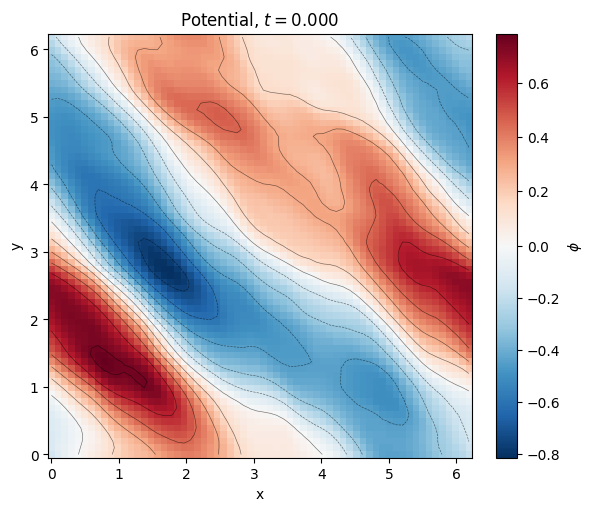

In [2]:
# True reproduce el barrido de test_dX_dY. False ofrece una comprobación rápida.
full_area_study = True
geometry = 'square'  # Cambia a 'circle' para repetir todo el estudio.
coupling_frequency = 0.0
rho = 0.3

potential = Potential.random(
    A=0.7,
    M=25,
    nx=64,
    ny=64,
    seed=27,
    interpolation_order=5,
)
center = (
    potential.grid.xmin + potential.grid.period / 2,
    potential.grid.ymin + potential.grid.period / 2,
)
_ = potential.plot()

In [3]:
# Resolución densa tomada de test_dX_dY para seguir la curvatura de los lados.
dense_square = Area.square(
    center=center,
    side=1.0,
    points_per_side=40 if full_area_study else 4,
    rho=rho,
)
dense_circle = Area.circle(
    center=center,
    radius=0.5,
    points=160 if full_area_study else 16,
    rho=rho,
)
area_trajectory = dense_square if geometry == 'square' else dense_circle
area_system = SystemGC(
    potential,
    area_trajectory,
    coupling_frequency=coupling_frequency,
)

# Misma geometría con ocho vértices: estado físico 16 y extendido 32.
diagnostic_square = Area.square(
    center=center,
    side=1.0,
    points_per_side=2,
    rho=rho,
)
diagnostic_circle = Area.circle(
    center=center,
    radius=0.5,
    points=8,
    rho=rho,
)
projected_area = diagnostic_square if geometry == 'square' else diagnostic_circle
projected_system = SystemGC(
    potential,
    projected_area,
    coupling_frequency=coupling_frequency,
)

print(
    f'Geometría: {geometry}; vértices área={area_trajectory.particle_count(area_trajectory.state)}, '
    f'vertices jacobiano={projected_area.particle_count(projected_area.state)}'
)

Geometría: square; vértices área=160, vertices jacobiano=8


## 1. Convergencia del área según el paso

Se transporta el mismo contorno denso con varios pasos. `Area.calculate_area(...)` aplica desempaquetado periódico antes de la fórmula del cordón.

In [4]:
area_steps = (0.01, 0.005, 0.0025) if full_area_study else (0.02, 0.01)
area_t_span = (0.0, 6 * np.pi) if full_area_study else (0.0, 0.2)
area_n_save_step = 361 if full_area_study else 11
area_solutions = {}
area_relative_errors = {}

for area_step in area_steps:
    area_solution = area_system.simulate(
        step=area_step,
        t_span=area_t_span,
        n_save_step=area_n_save_step,
        check_energy=False,
        progress=True,
    )
    area_values = area_trajectory.calculate_area(
        area_solution.y,
        period=potential.grid.period,
    )
    area_error = (area_values - area_values[0]) / abs(area_values[0])
    area_solutions[area_step] = area_solution
    area_relative_errors[area_step] = area_error

header = ('step', 'n_steps', 'max |error rel.|', 'error rel. final')
print(f'{header[0]:>10} {header[1]:>12} {header[2]:>20} {header[3]:>20}')
for area_step in area_steps:
    area_solution = area_solutions[area_step]
    area_error = area_relative_errors[area_step]
    print(
        f'{area_step:10.4g} {area_solution.n_steps:12d} '
        f'{np.max(np.abs(area_error)):20.8e} {area_error[-1]:20.8e}'
    )

SystemGC [==============================] 100.0% (2160/2160, t=18.8496)
SystemGC [==============================] 100.0% (3960/3960, t=18.8496)
SystemGC [==============================] 100.0% (7560/7560, t=18.8496)


      step      n_steps     max |error rel.|     error rel. final
      0.01         2160       1.05531683e-03      -1.05531683e-03
     0.005         3960       1.05531683e-03      -1.05531683e-03
    0.0025         7560       1.05531683e-03      -1.05531683e-03


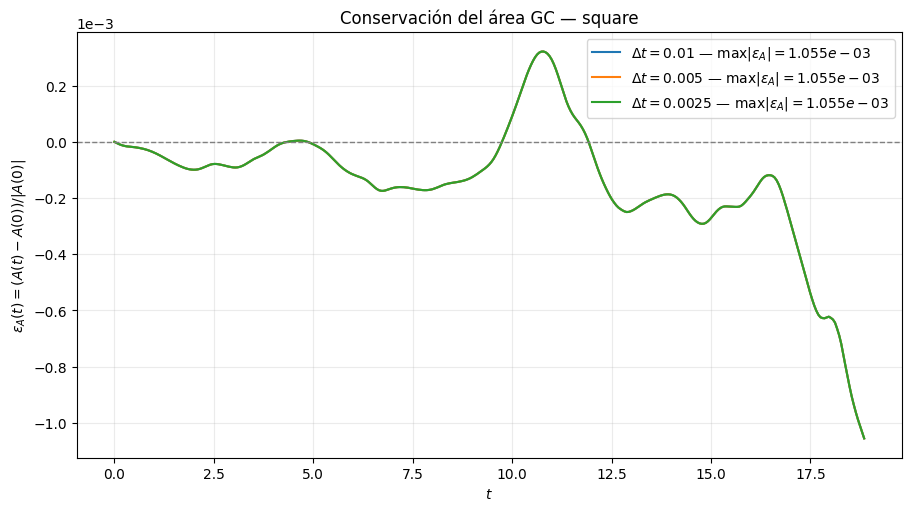

In [5]:
fig, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
for area_step in area_steps:
    area_solution = area_solutions[area_step]
    area_error = area_relative_errors[area_step]
    axis.plot(
        area_solution.t,
        area_error,
        label=(
            fr'$\Delta t={area_step:g}$'
            fr' — $\max|\varepsilon_A|={np.max(np.abs(area_error)):.3e}$'
        ),
    )
axis.axhline(0.0, color='0.5', ls='--', lw=1)
axis.set(
    xlabel='$t$',
    ylabel=r'$\varepsilon_A(t)=(A(t)-A(0))/|A(0)|$',
    title=f'Conservación del área GC — {geometry}',
)
axis.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
axis.grid(alpha=0.25)
axis.legend()
plt.show()

### Animación del área y de su error

El panel izquierdo muestra la deformación del contorno y el valor instantáneo $A(t)$. El panel derecho construye $\varepsilon_A(t)$ en el tiempo, marca el instante actual e indica tanto el error actual como el máximo acumulado $\max_{s\leq t}|\varepsilon_A(s)|$.

In [6]:
# El paso más fino sincroniza deformación del contorno y error de área.
finest_area_error = area_relative_errors[area_steps[-1]]
print(
    f'Paso fino {area_steps[-1]:g}: '
    f'max |error relativo|={np.max(np.abs(finest_area_error)):.8e}, '
    f'error final={finest_area_error[-1]:+.8e}'
)
area_animation = area_system.animate_area(
    area_solutions[area_steps[-1]],
    frames=180 if full_area_study else None,
    interval=50,
)
display_animation(area_animation)

Paso fino 0.0025: max |error relativo|=1.05531683e-03, error final=-1.05531683e-03


## 2. Simplecticidad y área del mapa proyectado

Sobre el contorno reducido se propaga $D(P\Phi E)$ durante el intervalo corto $0\leq t\leq1$. El observador registra también su área y la distancia entre las copias extendidas.

In [7]:
projected_step = 0.02
projected_t_span = (0.0, 1.0)
# Un estado guardado por paso permite animar toda la curva de error.
projected_n_save_step = int(round(
    (projected_t_span[1] - projected_t_span[0]) / projected_step
)) + 1

with ProjectedSymplecticityAreaObserver(
    notebook_path=NOTEBOOK_PATH,
    area=projected_area,
    period=potential.grid.period,
    project_root=PROJECT_ROOT,
    block_name='area_projected_symplecticity',
    record_every=1,
    chunk_size=10,
    verbose=True,
    metadata={
        'geometry': geometry,
        'coupling_frequency': coupling_frequency,
        'rho': rho,
        'integration_step': projected_step,
        'potential_seed': 27,
    },
) as projected_observer:
    projected_solution = projected_system.simulate(
        step=projected_step,
        t_span=projected_t_span,
        n_save_step=projected_n_save_step,
        check_energy=False,
        progress=False,
        stage_observer=projected_observer,
    )

projected_records = projected_observer.records
projected_output_blocks = projected_observer.output_blocks
print(f'Observaciones proyectadas: {len(projected_records)}')
print(f'Salida: {projected_observer.output_directory}')
for block in projected_output_blocks:
    print(
        f'Bloque {block.index:05d}: {block.sample_count} proyecciones -> '
        f'{block.jacobians_path.name}'
    )

[projected] step=-0001 t=0 relative_defect=0.000e+00 relative_area_error=+0.000e+00 copy_separation=0.000e+00
[projected] step=00000 t=0.02 relative_defect=2.979e-11 relative_area_error=-1.366e-03 copy_separation=3.175e-11
[projected] step=00001 t=0.04 relative_defect=6.251e-11 relative_area_error=-2.691e-03 copy_separation=2.329e-11
[projected] step=00002 t=0.06 relative_defect=9.615e-11 relative_area_error=-3.971e-03 copy_separation=4.092e-11
[projected] step=00003 t=0.08 relative_defect=1.349e-10 relative_area_error=-5.202e-03 copy_separation=6.307e-11
[projected] step=00004 t=0.1 relative_defect=1.735e-10 relative_area_error=-6.382e-03 copy_separation=8.427e-11
[projected] step=00005 t=0.12 relative_defect=1.962e-10 relative_area_error=-7.508e-03 copy_separation=1.038e-10
[projected] step=00006 t=0.13 relative_defect=2.103e-10 relative_area_error=-8.050e-03 copy_separation=1.043e-10
[projected] step=00007 t=0.14 relative_defect=2.116e-10 relative_area_error=-8.579e-03 copy_separati

Las matrices y resúmenes se guardan en:

```text
outputs/developements/study_gc_area_and_projected_symplecticity/AAAA-MM-DD/
├── area_projected_symplecticity_summary_00000.csv
├── area_projected_symplecticity_jacobians_00000.npz
└── area_projected_symplecticity_metadata_00000.json
```

### Animación del contorno proyectado

Esta segunda animación aplica la misma visualización al contorno reducido utilizado para $DG$: permite comparar directamente su defecto simpléctico con la evolución temporal de $\varepsilon_A$.

In [8]:
projected_area_animation = projected_system.animate_area(
    projected_solution,
    frames=None,
    interval=75,
)
display_animation(projected_area_animation)

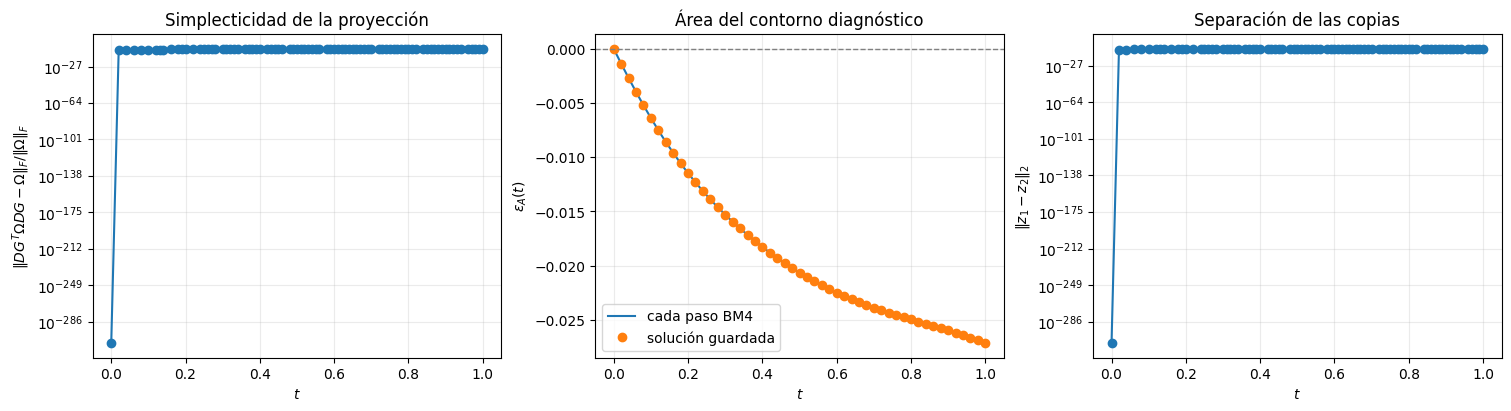

In [9]:
projected_times = np.asarray([record.time for record in projected_records])
projected_defects = np.asarray(
    [record.relative_defect for record in projected_records]
)
projected_area_errors = np.asarray(
    [record.relative_area_error for record in projected_records]
)
copy_separations = np.asarray(
    [record.copy_separation for record in projected_records]
)
saved_projected_areas = projected_area.calculate_area(
    projected_solution.y,
    period=potential.grid.period,
)
saved_projected_area_errors = (
    (saved_projected_areas - saved_projected_areas[0])
    / abs(saved_projected_areas[0])
)
positive_floor = np.finfo(float).tiny

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].semilogy(
    projected_times,
    np.maximum(projected_defects, positive_floor),
    'o-',
)
axes[0].set(
    title='Simplecticidad de la proyección',
    xlabel='$t$',
    ylabel=r'$\|DG^T\Omega DG-\Omega\|_F/\|\Omega\|_F$',
)
axes[1].plot(projected_times, projected_area_errors, '-', label='cada paso BM4')
axes[1].plot(
    projected_solution.t,
    saved_projected_area_errors,
    'o',
    label='solución guardada',
)
axes[1].axhline(0.0, color='0.5', ls='--', lw=1)
axes[1].set(
    title='Área del contorno diagnóstico',
    xlabel='$t$',
    ylabel=r'$\varepsilon_A(t)$',
)
axes[1].legend()
axes[2].semilogy(
    projected_times,
    np.maximum(copy_separations, positive_floor),
    'o-',
)
axes[2].set(
    title='Separación de las copias',
    xlabel='$t$',
    ylabel=r'$\|z_1-z_2\|_2$',
)
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

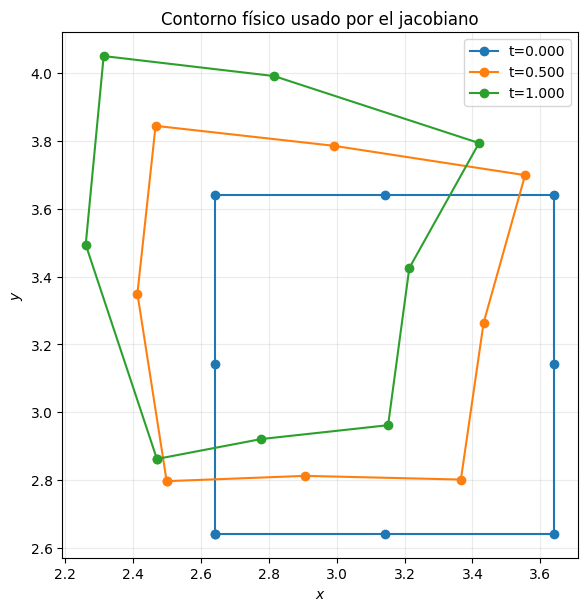

In [10]:
components = projected_solution.components()
fig, axis = plt.subplots(figsize=(6, 6), constrained_layout=True)
for index in (0, len(projected_solution.t) // 2, len(projected_solution.t) - 1):
    x = components.x[:, index]
    y = components.y[:, index]
    axis.plot(
        np.r_[x, x[0]],
        np.r_[y, y[0]],
        marker='o',
        label=f't={projected_solution.t[index]:.3f}',
    )
axis.set(
    title='Contorno físico usado por el jacobiano',
    xlabel='$x$',
    ylabel='$y$',
    aspect='equal',
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

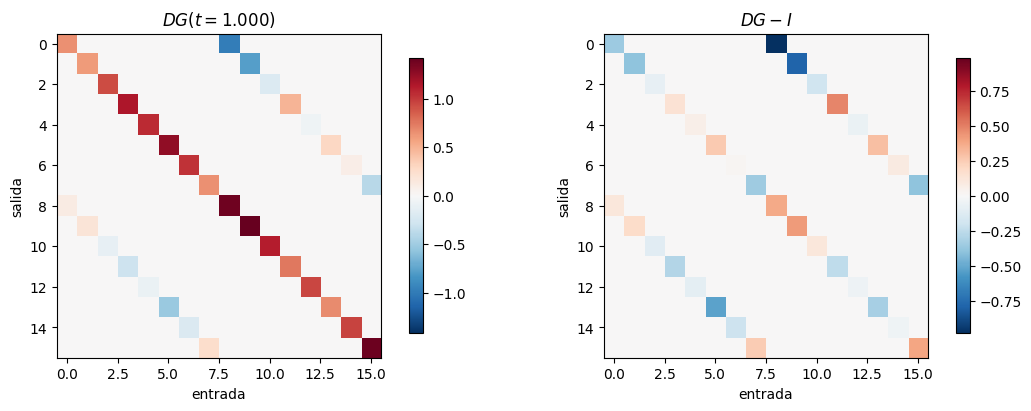

In [11]:
stored_jacobians = []
stored_times = []
for block in projected_output_blocks:
    with np.load(block.jacobians_path) as stored:
        stored_jacobians.append(stored['projected_jacobians'].copy())
        stored_times.append(stored['times'].copy())
projected_jacobians = np.concatenate(stored_jacobians)
jacobian_times = np.concatenate(stored_times)

final_jacobian = projected_jacobians[-1]
difference = final_jacobian - np.eye(final_jacobian.shape[0])
limit = max(float(np.max(np.abs(final_jacobian))), 1.0)
difference_limit = max(float(np.max(np.abs(difference))), np.finfo(float).eps)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
images = [
    axes[0].imshow(final_jacobian, cmap='RdBu_r', vmin=-limit, vmax=limit),
    axes[1].imshow(
        difference,
        cmap='RdBu_r',
        vmin=-difference_limit,
        vmax=difference_limit,
    ),
]
axes[0].set(
    title=fr'$DG(t={jacobian_times[-1]:.3f})$',
    xlabel='entrada',
    ylabel='salida',
)
axes[1].set(title=r'$DG-I$', xlabel='entrada', ylabel='salida')
for axis, image in zip(axes, images, strict=True):
    fig.colorbar(image, ax=axis, shrink=0.85)
plt.show()

## Lectura conjunta

El barrido denso separa el error de integración mediante su dependencia con $\Delta t$. El segundo bloque mide la simplecticidad local acumulada del mapa proyectado y permite relacionarla con el área del mismo tipo de contorno. Las curvas de área de ambas resoluciones no deben coincidir exactamente: un flujo que preserva área puede curvar los segmentos entre vértices y alterar la aproximación poligonal, especialmente en el contorno reducido.